## 1. Librerías y cargado del dataset


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, RocCurveDisplay)

from google.colab import drive


# Se carga el dataset
drive.mount('/content/drive')

path = '/content/drive/MyDrive/TFM/data/cleaned_dataset.csv'
df = pd.read_csv(path,encoding='Latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Exploración inicial del dataset

In [25]:
# Dimensiones, nulos y tipos
print("Dimensiones:", df.shape)
print(df.info())
print(df["DIABETE3"].value_counts(normalize=True))

Dimensiones: (257709, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257709 entries, 0 to 257708
Data columns (total 23 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   257709 non-null  float64
 1   BPHIGH4   257709 non-null  float64
 2   BPMEDS    257709 non-null  float64
 3   BLOODCHO  257709 non-null  float64
 4   HAVARTH3  257709 non-null  float64
 5   ADDEPEV2  257709 non-null  float64
 6   DIABETE3  257709 non-null  float64
 7   SEX       257709 non-null  float64
 8   QLACTLM2  257709 non-null  float64
 9   USEEQUIP  257709 non-null  float64
 10  BLIND     257709 non-null  float64
 11  DECIDE    257709 non-null  float64
 12  DIFFWALK  257709 non-null  float64
 13  DIFFDRES  257709 non-null  float64
 14  DIFFALON  257709 non-null  float64
 15  SMOKE100  257709 non-null  float64
 16  EXEROFT1  257709 non-null  float64
 17  _RACE     257709 non-null  float64
 18  _AGEG5YR  257709 non-null  float64
 19  _BMI5CAT  257709 n

In [26]:
# Se normaliza el target
df["DIABETE3"] = df["DIABETE3"].map({1.0: 1, 3.0: 0})
df["DIABETE3"].value_counts()

,count
DIABETE3,
0,229318
1,28391


/tmp/ipython-input-4029100069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


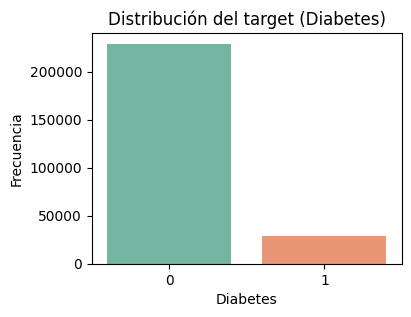

In [27]:
# Distribución del target
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución del target (Diabetes)")
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")
plt.show()

## 3. Análisis Exploratorio de Datos (EDA)

In [28]:
# Se definen las categorías de variables
categorical_nominal = [
    'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2',
    'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES',
    'DIFFALON', 'SMOKE100', 'ADDEPEV2', '_RACE', 'SEX'
]
categorical_ordinal = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']
numeric_vars = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']
target = "DIABETE3"

El EDA completo por grupos de las variables se realizó en model_training_v1.ipynb

## 4. División del dataset

In [29]:
# Se divide en entrenamiento (60%), validación (20%) y test (20%).
X = df.drop(target, axis=1)
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (154625, 22), Val: (51542, 22), Test: (51542, 22)


## 5. Pipelines de preprocesamiento

In [30]:
# Nueva lista de columnas en función del tratamiento
# Se separan las nominales con varias categorías de las que serán binarias
categorical_nominal = ['BPHIGH4', '_RACE']
binary_vars = ['BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFALON','DIFFDRES', 'SMOKE100', 'ADDEPEV2', 'SEX']

categorical_ordinal = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']
numeric_vars = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']

### 5.1. Preprocesamiento determinista

In [31]:
# No dependen de la distribución de los datos (media, mediana...). Siempre producen el mismo resultado para un mismo input (cambiar -1 por NaN)

# Para RF:
def rf_deterministic_preproc(X):
    X = X.copy()
    X = X.replace(-1, np.nan) # Se reemplazará en todo el dataset los valores -1 por NaN

    for col in binary_vars: # En columnas binarias, se cambia NaN (false) por 0
        X[col] = (X[col]==1).astype(int)

    return X

# Para XGB y Light:
def boosting_deterministic_preproc(X):
    X = X.copy()
    X = X.replace(-1, np.nan) # Se reemplazará en todo el dataset los valores -1 por NaN

    for col in binary_vars: # En columnas binarias, se cambia NaN (false) por 0
        X[col] = (X[col]==1).astype(int)

    # Se convierten solo las nominales de XGB/LightGBM a category. En RF se aplicará One Hot
    for col in categorical_nominal:
        X[col] = X[col].astype('category')
    return X

### 5.2. Preprocesamiento de numéricas (Capping de outliers)

In [32]:
def cap_outliers_numeric(X, numeric_vars):
    X = X.copy()
    for col in numeric_vars:
        low = np.nanpercentile(X[col], 1)
        high = np.nanpercentile(X[col], 99)
        X[col] = X[col].clip(low, high)
    return X

### 5.3. Transformadores por tipo de variable

In [33]:
# Categóricas nominales para RF: Most frequent y OneHot
nominal_pipeline_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [34]:
# Categóricas nominales para XGB/LightGBM: Most frequent
nominal_pipeline_boosting = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [35]:
# Categóricas ordinales: Most frequent (ya está codificadas las clases correctamente)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [36]:
# Numéricas: Función propia y Median
numeric_pipeline = Pipeline(steps=[
    ('cap_outliers', FunctionTransformer(
        func=cap_outliers_numeric, # Se utiliza la función definida antes
        kw_args={'numeric_vars': numeric_vars}, # Se le pasa de argumento la lista de variables numéricas
        validate=False # Se acepta el df sin convertirlo a un array de NumPy
    )),
    ('imputer', SimpleImputer(strategy='median'))
])

In [37]:
# ColumnTransformer:
# Para RF
preprocessor_rf = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline_rf, categorical_nominal),
    ('bin', 'passthrough', binary_vars), # passthrough indica que no se aplique ninguna transformación (se hizo en Preprocesarmiento determinista)
    ('ord', ordinal_transformer, categorical_ordinal),
    ('num', numeric_pipeline, numeric_vars)
])

#Para XGB y LIGHT
preprocessor_boosting = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline_boosting, categorical_nominal),
    ('bin', 'passthrough', binary_vars), # passthrough indica que no se aplique ninguna transformación (se hizo en Preprocesarmiento determinista)
    ('ord', ordinal_transformer, categorical_ordinal),
    ('num', numeric_pipeline, numeric_vars)
])

## 6. Definición de modelos

In [38]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, # suficientes árboles para estabilidad
    max_depth=None, # deja crecer hasta que las hojas sean 'puras'
    min_samples_split=10, # evita sobreajuste en hojas pequeñas
    min_samples_leaf=5, # evita hojas muy pequeñas
    class_weight='balanced', # ajusta automáticamente para desbalance de clases
    n_jobs=-1, # usa todos los cores disponibles
    random_state=42
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6, # profundidad moderada
    learning_rate=0.1, # tasa de aprendizaje estándar
    subsample=0.8, # reduce overfitting
    colsample_bytree=0.8, # aleatoriza columnas por árbol
    scale_pos_weight=0.89/0.11,  # compensar desbalance de clases
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=-1, # sin límite de profundidad
    num_leaves=31, # tamaño moderado del árbol
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced', # ajusta desbalance automáticamente, es un target muy desbalanceado
    n_jobs=-1,
    random_state=42
)

In [39]:
# Pipelines finales
models = {
    'Random Forest': Pipeline([
    ('deterministic', FunctionTransformer(rf_deterministic_preproc)),
    ('preprocessor', preprocessor_rf),
    ('model', rf_model)
]),
    'XGBoost': Pipeline([
    ('deterministic', FunctionTransformer(boosting_deterministic_preproc)),
    ('preprocessor', preprocessor_boosting),
    ('model', xgb_model)
]),
    'LightGBM': Pipeline([
    ('deterministic', FunctionTransformer(boosting_deterministic_preproc)),
    ('preprocessor', preprocessor_boosting),
    ('model', lgb_model)
])
}

### 6.1. Validación cruzada

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'}
cv_results = []

for name, pipe in models.items():
    # cross_validate devuelve dict con test_roc_auc y test_pr_auc
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Model': name,
        'ROC-AUC (CV mean)': scores['test_roc_auc'].mean(),
        'PR-AUC (CV mean)': scores['test_pr_auc'].mean(),
        'ROC-AUC (CV std)': scores['test_roc_auc'].std()
    })

In [41]:
df_cv = pd.DataFrame(cv_results)
print("=== VALIDACIÓN CRUZADA ===")
display(df_cv)

=== VALIDACIÓN CRUZADA ===


,Model,ROC-AUC (CV mean),PR-AUC (CV mean),ROC-AUC (CV std)
0,Random Forest,0.835550,0.377734,0.001848
1,XGBoost,0.836881,0.384318,0.002233
2,LightGBM,0.839270,0.390049,0.001657


In [48]:
# Mejor modelo según PR-AUC CV
best_model_name = df_cv.sort_values('PR-AUC (CV mean)', ascending=False).iloc[0]['Model']
print(f"Mejor modelo: {best_model_name}")

Mejor modelo: LightGBM


## 7. Entrenamiento y evaluación

In [42]:
# Threshold para convertir probabilidades en clases binarias
threshold = 0.25

# Listas para almacenar resultados de métricas
results_val = []
results_test = []

### 7.1. Iteración sobre los modelos

In [43]:
# Se entrena cada modelo y se calculan las métricas de evaluación para validación y test.
for idx, (name, pipe) in enumerate(models.items()):

    # Entrenamiento del modelo
    pipe.fit(X_train, y_train)

    # Evaluación en el conjunto de Validación
    y_prob_val = pipe.predict_proba(X_val)[:, 1]
    y_pred_val = (y_prob_val >= threshold).astype(int)

    precision_val, recall_vals_val, _ = precision_recall_curve(y_val, y_prob_val)
    results_val.append({
        'Model': name,
        'Recall': recall_score(y_val, y_pred_val),
        'F1-score': f1_score(y_val, y_pred_val),
        'ROC-AUC': roc_auc_score(y_val, y_prob_val),
        'PR-AUC': auc(recall_vals_val, precision_val)
    })

    # Evaluación en el conjunto de Test
    y_prob_test = pipe.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= threshold).astype(int)

    precision_test, recall_vals_test, _ = precision_recall_curve(y_test, y_prob_test)
    results_test.append({
        'Model': name,
        'Recall': recall_score(y_test, y_pred_test),
        'F1-score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test),
        'PR-AUC': auc(recall_vals_test, precision_test)
    })

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:18:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 17035, number of negative: 137590
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023735 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 563
[LightGBM] [Info] Number of data points in the train set: 154625, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 7.2. Matrices de confusión

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


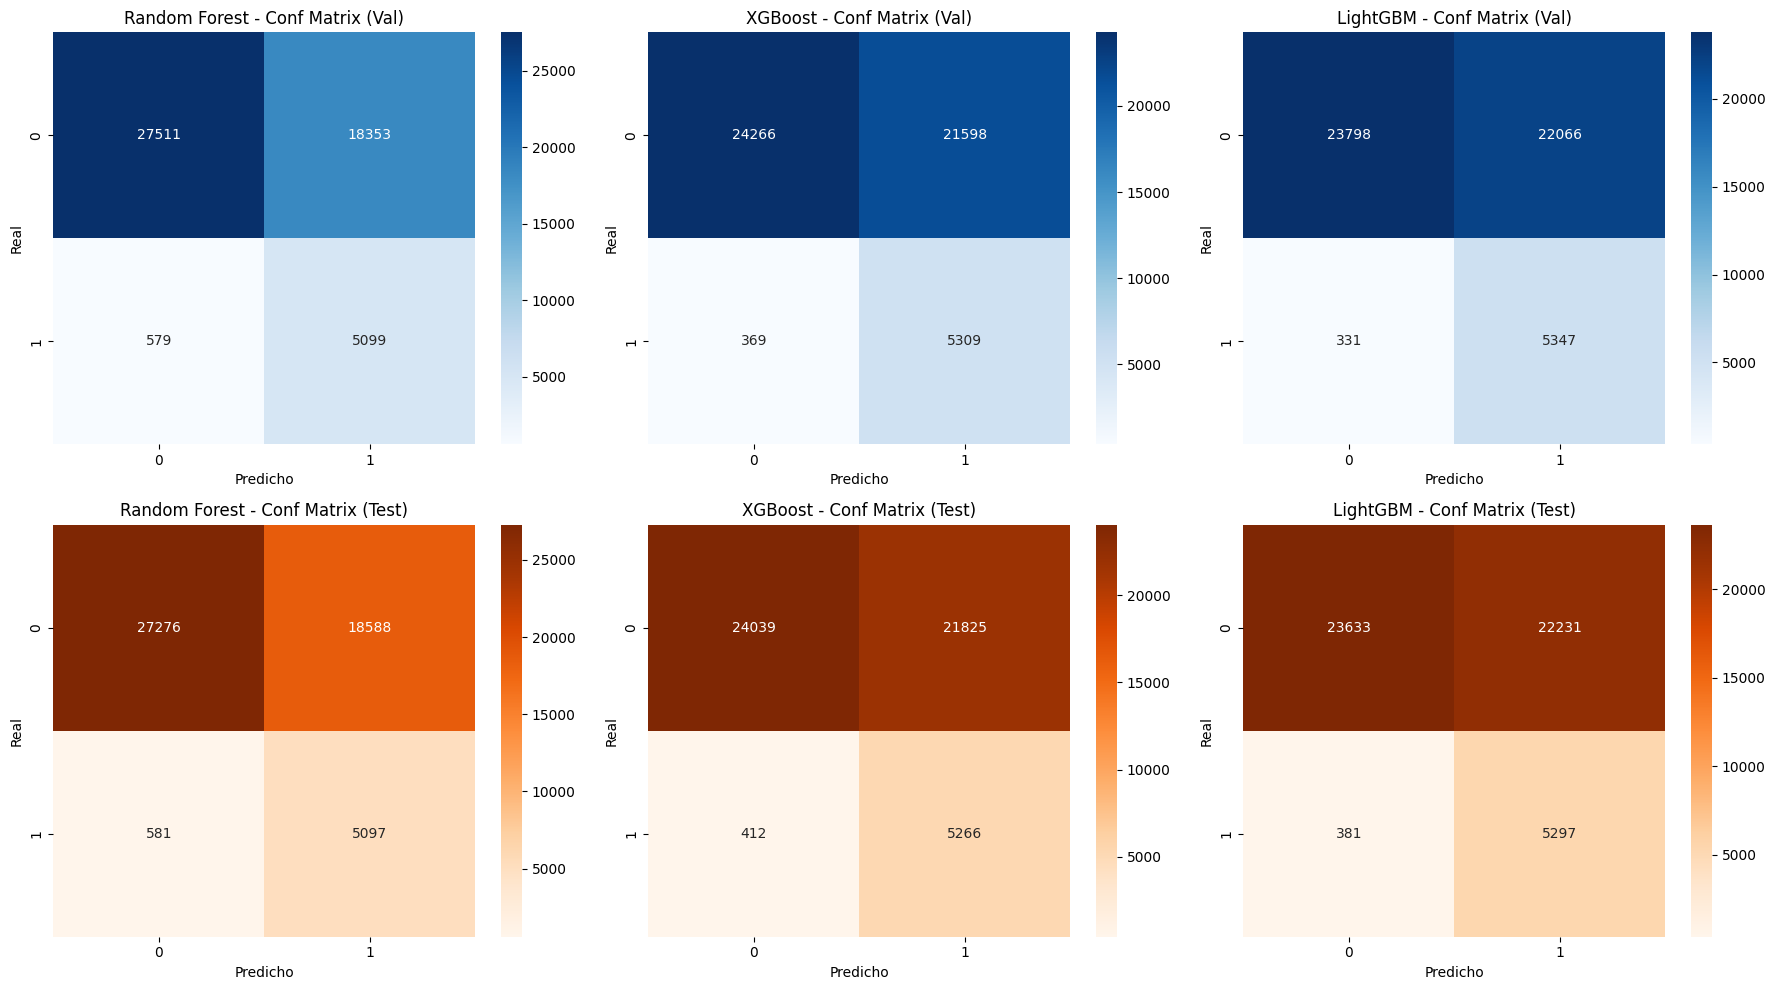

In [44]:
# Se crea una figura para matrices de confusión: 2 filas (Val/Test) x 3 columnas (modelos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, pipe) in enumerate(models.items()):
    # Validación
    cm_val = confusion_matrix(y_val, (pipe.predict_proba(X_val)[:,1] >= threshold).astype(int))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1], ax=axes[0, idx])
    axes[0, idx].set_title(f'{name} - Conf Matrix (Val)')
    axes[0, idx].set_xlabel('Predicho')
    axes[0, idx].set_ylabel('Real')

    # Test
    cm_test = confusion_matrix(y_test, (pipe.predict_proba(X_test)[:,1] >= threshold).astype(int))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', xticklabels=[0,1], yticklabels=[0,1], ax=axes[1, idx])
    axes[1, idx].set_title(f'{name} - Conf Matrix (Test)')
    axes[1, idx].set_xlabel('Predicho')
    axes[1, idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

### 7.3. Curvas ROC (RocCurveDisplay)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


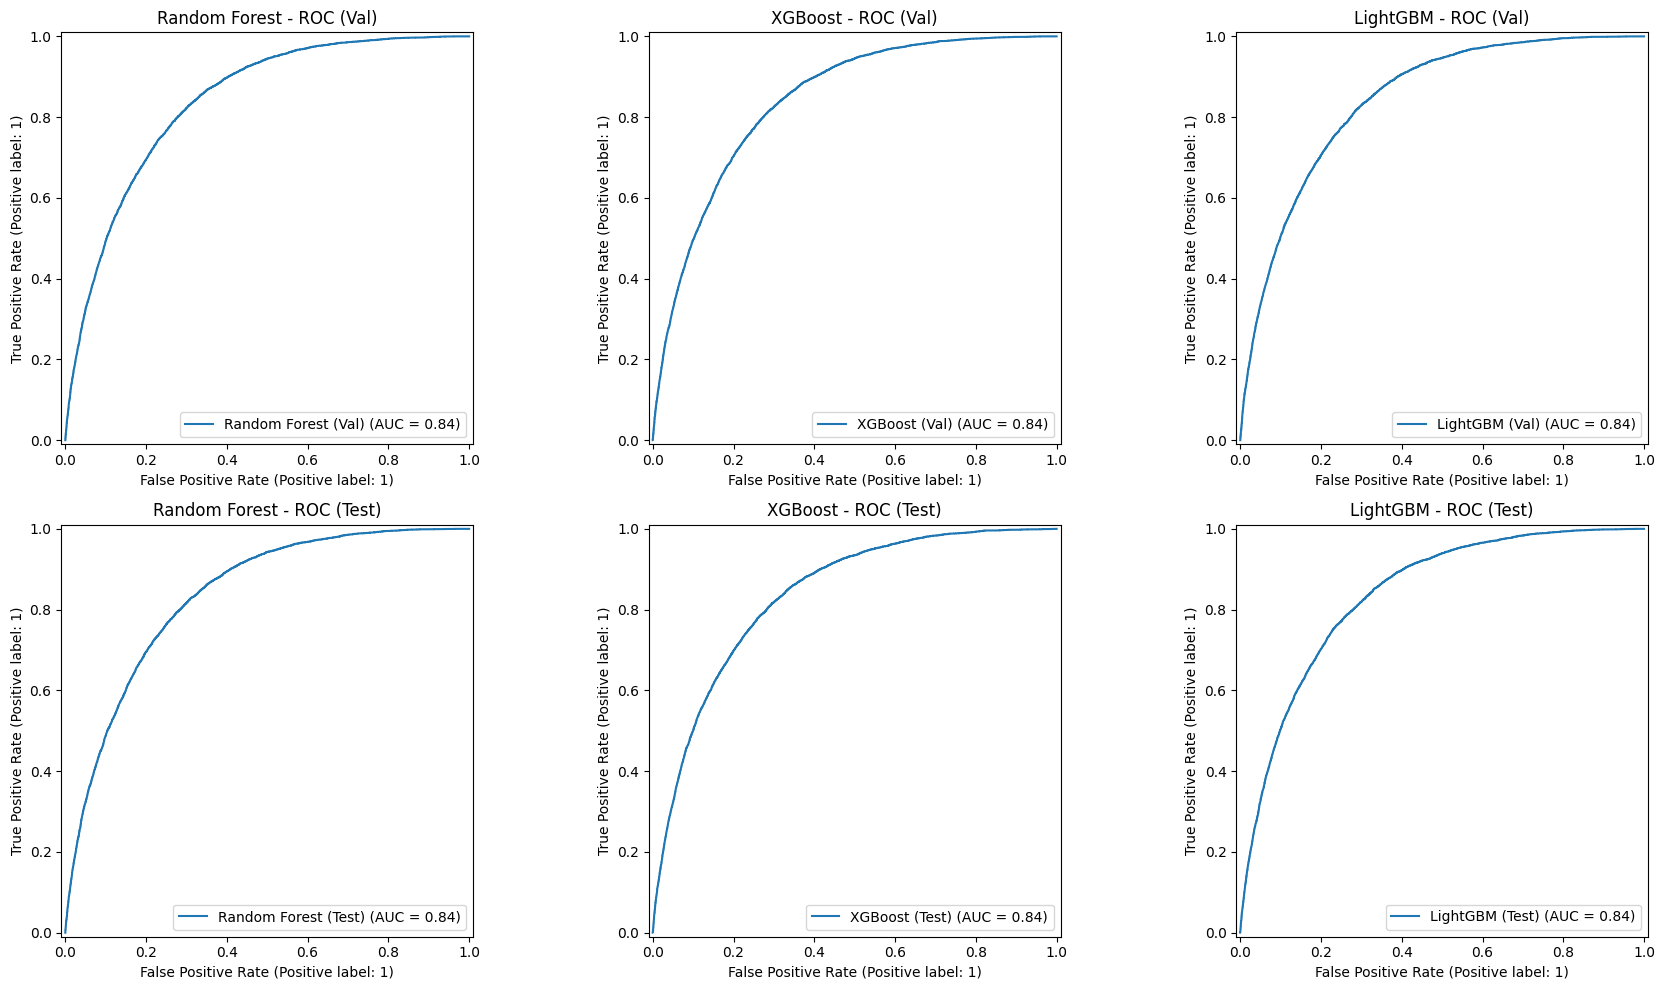

In [45]:
# Se crea una figura para curvas ROC: 2 filas (Val/Test) x 3 columnas (modelos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, pipe) in enumerate(models.items()):

    # Validación
    y_prob_val = pipe.predict_proba(X_val)[:,1]
    RocCurveDisplay.from_predictions(y_val, y_prob_val, name=f"{name} (Val)", ax=axes[0, idx])
    axes[0, idx].set_title(f'{name} - ROC (Val)')

    # Test
    y_prob_test = pipe.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(y_test, y_prob_test, name=f"{name} (Test)", ax=axes[1, idx])
    axes[1, idx].set_title(f'{name} - ROC (Test)')

plt.tight_layout()
plt.show()

### 7.4 Resultados finales

In [46]:
df_results_val = pd.DataFrame(results_val)
df_results_test = pd.DataFrame(results_test)

print("=== VALIDATION SET ===")
display(df_results_val)

print("=== TEST SET ===")
display(df_results_test)

=== VALIDATION SET ===


,Model,Recall,F1-score,ROC-AUC,PR-AUC
0,Random Forest,0.898027,0.350086,0.837691,0.378081
1,XGBoost,0.935012,0.325855,0.839667,0.381261
2,LightGBM,0.941705,0.323169,0.842493,0.388319


=== TEST SET ===


,Model,Recall,F1-score,ROC-AUC,PR-AUC
0,Random Forest,0.897675,0.347172,0.835613,0.376176
1,XGBoost,0.927439,0.321401,0.836137,0.379031
2,LightGBM,0.932899,0.319039,0.838338,0.382679


### 7.5. Importancia de variables

In [47]:
# Cálculo de importancia
# Se crea un diccionario vacío donde se almacenará la importancia de las variables para cada modelo
importancias_modelos = {}

for name, pipe in models.items():
    # Se extrae el modelo final
    modelo_final = pipe.named_steps['model']

    # Se extraen los nombres de features después del preprocesador
    preprocessor = pipe.named_steps['preprocessor']
    feature_names = []

    # Numéricas, no se expanden ni transforman en cantidad de columnas
    feature_names.extend(numeric_vars)

    # Binarias, no se expanden ni transforman en cantidad de columnas
    feature_names.extend(binary_vars)

    # Nominales:
    if name == "Random Forest":
        # RF usa OneHotEncoder, las columnas se expanden
        nom_transformer = preprocessor.named_transformers_['nom']
        if hasattr(nom_transformer, 'named_steps'):
            nominal_ohe = nom_transformer.named_steps['onehot']
        else:
            nominal_ohe = nom_transformer
        nominal_features = nominal_ohe.get_feature_names_out(categorical_nominal)
        feature_names.extend(nominal_features)
    else:
        # XGB / LightGBM son categorías nativas, no se expanden
        feature_names.extend(categorical_nominal)

    # Ordinales, ya estaban codificadas, no fue necesario expandirlas
    feature_names.extend(categorical_ordinal)

    # Se calcula la importancia según el tipo de modelo
    if hasattr(modelo_final, 'feature_importances_'):
        importances = modelo_final.feature_importances_
    else:
        importances = None

    # Validación y construcción del DataFrame
    if importances is not None and len(importances) == len(feature_names):
        df_importance = pd.DataFrame({
            'Variable': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        importancias_modelos[name] = df_importance

# Mostrar top 10 variables por modelo
if importancias_modelos:
    for modelo, df_imp in importancias_modelos.items():
        print(f"\nTop 10 variables más importantes para {modelo}:")
        print(df_imp.head(10).to_string(index=False))
else:
    print("No hay importancias para mostrar. Revisar modelos y atributos.")


Top 10 variables más importantes para Random Forest:
   Variable  Importance
  _RACE_6.0    0.136891
  _RACE_8.0    0.115590
   DIFFDRES    0.103718
   _BMI5CAT    0.091884
   EXEROFT1    0.085686
   _AGEG5YR    0.075889
    GENHLTH    0.074678
   _VEGESUM    0.060174
    _PACAT1    0.057705
BPHIGH4_4.0    0.023607

Top 10 variables más importantes para XGBoost:
Variable  Importance
_VEGESUM    0.467408
     SEX    0.109166
EXEROFT1    0.100597
 GENHLTH    0.051509
   _RACE    0.040677
  BPMEDS    0.032110
ADDEPEV2    0.021168
  DECIDE    0.020687
_FRUTSUM    0.018322
QLACTLM2    0.017198

Top 10 variables más importantes para LightGBM:
Variable  Importance
_BMI5CAT        1143
_AGEG5YR         917
   _RACE         712
 _PACAT1         617
     SEX         477
 GENHLTH         358
_FRUTSUM         269
 BPHIGH4         213
EXEROFT1         160
ADDEPEV2         159
